# Laboratorium 3


In [1]:
import numpy as np

## Zadanie 1.11[MG&AC&MB]

Zaimplementuj funkcję, która dla danego wektora $\mathtt{x}$ o długości $d$ oraz nieparzystej liczby naturalnej $k$ wyznaczy średnią ruchomą, $k<d$, tj. taki wektor $(w_1, w_2, \dots, w_{d-k+1})$, że
$$w_i = \sum_{j=1}^{k}\frac{x_{i+j-1}}{k}.$$


In [2]:
import numpy as np
import matplotlib.pyplot as plt

def srednia_ruchoma(x, k):
    """
    Funkcja wyznacza średnią ruchomą dla danego
    wektra x
    
    Więcej szczegółów w pliku .pdf, .html lub .ipynb
    Parameters
    ----------
    x : tablica numpy.ndarray jednowymiarowa  
        (wektor)
    
    Returns
    -------
    Tablica numpy.ndarray jednowymiarowa  
    (wektor)
    """
    # 1.) np.cumsum() - skumulowane sumy
    w = np.cumsum(x)
    # 2.) odejmujemy od sum skumulowanych 
    #     wartości elementów tak by uzyskac tylko
    #     sumy k kolejnych elementów
    w[k:] -= w[:-k]
    # 3.) Wykorzystujemy wektoryzację wektor i skalar
    #     by każdą taka sumę podzielić przez k
    return w[(k-1):]/k

In [3]:
def srednia_ruchoma2(x, k):
    
    return np.convolve(x, np.ones(k), 'valid') / k

def srednia_ruchoma3(x, k):
    
    import pandas as pd

    w = pd.Series(x)

    return w.rolling(k).mean()

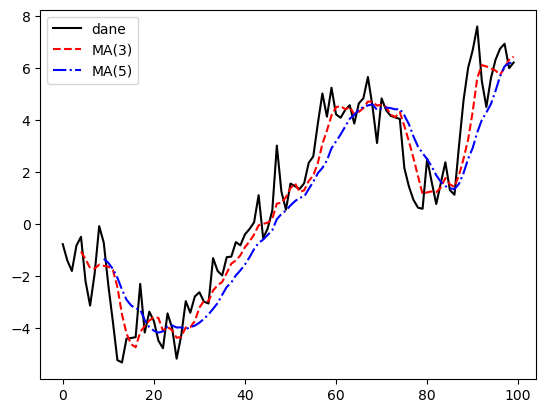

In [4]:
# Jako przykład wygenerujemy rysunek:
# Generujemy dane:
x = np.random.randn(100)
y = x.cumsum()
# Funkcja plt.plot() rysuje krzywą łącząc punkty zawarte
# w tablicy y
plt.plot(y, 'k-', label="dane") # 'k-' wygląd krzywej (czarna, ciągła)
k = 5
plt.plot(range(k-1, len(y)), srednia_ruchoma(y, k), 'r--', label="MA(3)") # 'r--` (czerwona, przerywana)
k = 10
plt.plot(range(k-1, len(y)), srednia_ruchoma(y, k), 'b-.', label="MA(5)") # 'b-.' (niebieska, kropka-kreska

plt.legend() # legenda (korzysta z etykiet label)
plt.show()

## Zadanie 1.12[MG]

Niech `t` będzie wektorem o $n$ elementach będących liczbami całkowitymi ze zbioru $\{1,\dots,k\}$. 
Napisz funkcję, która dokona kodowania elementów $t_i$ (*one-hot-encode*).
Funkcja powinna zwracać macierz zero-jedynkową $R$ wymiaru $n\times k$ taką, że 
$r_{i,j}=1$ wtedy i tylko wtedy gdy $t_i = j$. Taka reprezentacja jest przydatna 
np. w problemie klasyfikacji wieloetykietowej przy użyciu $k$ klasyfikatorów.


In [5]:
import numpy as np

def onehotencode(t):
    """
    One-hot-encoder
    
    Parameters
    ----------
    t : vector (one dimensional numpy.ndarray array) 

    Returns
    -------
    Function return a 0-1 matrix of size nxk (numpy.ndarray)
    
    """
    assert t.ndim == 1
    
    n = t.shape[0] # liczba wierszy
    k = t.max()    # liczba kolumn wyniku
    # przygotujemy macierz odpowiedniego wymiaru
    # wypelnioną 0
    M = np.zeros((n, k)) 
    # Wykorzystamy indeksowanie: ciąg indeksów (lista) 
    # oraz ciąg indeksów (tablca t)
    # wybieramy elementy:
    # M[ind1[0], ind2[0]], M[ind1[1], ind2[1]], ....
    # i zmienimy ich wartość
    M[ [i for i in range(n)], t-1 ] = 1 # t-1 bo indeksujemy od 0
    # M[ list(range(n)), t-1] = 1 
    return(M)

In [6]:
t = np.array([1, 3, 1, 2, 5, 5, 5])
print(onehotencode(np.array([1, 3, 1, 2, 5, 5, 5])))
t.shape

[[1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]]


(7,)

In [7]:
def onehotencoder2(t):

    import pandas as pd
    #from sklearn.preprocessing import LabelEncoder
    from sklearn.preprocessing import OneHotEncoder
    
    # binary encode
    onehot_encoder = OneHotEncoder()
    return onehot_encoder.fit_transform(pd.DataFrame(t)).toarray()

def onehotedecode(X):
    """
    One-hot-decoder
    
    Parameters
    ----------
    X : matrix (two dimensional numpy.ndarray array) 

    Returns
    -------
    Function return a vector (one dimensional numpy.ndarray)
    sutch that for each row the number of the column with the
    value most close to 1 is returned
    """        
    # w której kolumnie wartość największa 
    # argmax zwraca indeks pierwszego maksimum (idziemy po kolumnach)
    return X.argmax(axis = 1) + 1

In [8]:
onehotencoder2(np.array([1, 3, 1, 2, 5, 5, 5]))

array([[1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.]])

## Zadanie 1.13 [MG]

Dokonaj przekształcenia \textit{softmax} każdego wiersza macierzy 
$\mathbf{X}\in\mathbb{R}^{n\times k}$, tzn. przekształcenia postaci: 
$$x_{i,j}\mapsto \frac{\exp(x_{i,j})}{\sum_{l=1}^k \exp(x_{i,l})}.$$

Następnie dokonaj odkodowania każdego wiersza (\textit{one-hot decode}), 
tj. dla każdego wiersza należy znaleźć numer kolumny o wartości najbardziej 
zbliżonej do $1$. Zwróć wektor $n$-elementowy.


In [9]:
def softmax1(X):
    r"""
    Softmax transformation
    i.e.
    x_{ij} -> ( exp(x_{ij}) / \sum_{l=1}^{k} exp_{x_{il}} )
    
    Parameters
    ----------
    X : matrix (two dimensional numpy.ndarray array) 

    Returns
    -------
    Function return transformed matrix of size nxk (numpy.ndarray)
    """    
    import scipy.special 
    
    return scipy.special.softmax(X, axis=1)

In [10]:
def softmax2(X):
    r"""
    Softmax transformation
    i.e.
    x_{ij} -> ( exp(x_{ij}) / \sum_{l=1}^{k} exp_{x_{il}} )
    
    Parameters
    ----------
    X : matrix (two dimensional numpy.ndarray array) 

    Returns
    -------
    Function return transformed matrix of size nxk (numpy.ndarray)
    """    
    Y = np.exp(X) # funkcja zwektoryzowana
    # 1.) axis - po której będziemy liczyć sumę
    # tu 1 czyli dostaniemy wartości sumy w każdym wierszu
    # liczymy po kolumnach
    # 2.) (-1, 1) automatyczne dostosowanie liczby wierszy, 1 kolumna
    # dzieki temu dostaniemy wektoryzację po kolumnach
    return Y / Y.sum(axis = 1).reshape(-1, 1) 

In [11]:
X = np.random.rand(12).reshape(-1, 3)
print(X)
print(X.shape)

[[0.66675219 0.9161173  0.82943885]
 [0.09184287 0.86202372 0.09068499]
 [0.11518693 0.04518524 0.42965062]
 [0.15361284 0.45093637 0.74898795]]
(4, 3)


In [12]:
Y1 = softmax1(X)
Y2 = softmax2(X)

print(onehotedecode(Y1))
# itd.

onehotencoder2(np.array([1, 3, 1, 2, 5, 5]))

[2 2 3 3]


array([[1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.]])

In [13]:
Y3 = X*1000


In [14]:
softmax1(Y3)

array([[5.03626907e-109, 1.00000000e+000, 2.27001114e-038],
       [0.00000000e+000, 1.00000000e+000, 0.00000000e+000],
       [2.69248513e-137, 1.06858374e-167, 1.00000000e+000],
       [2.70317669e-259, 3.61278037e-130, 1.00000000e+000]])

In [15]:
softmax2(Y3)

C:\Users\malys\AppData\Local\Temp\ipykernel_37916\2323221940.py:15: RuntimeWarning: overflow encountered in exp
  Y = np.exp(X) # funkcja zwektoryzowana
C:\Users\malys\AppData\Local\Temp\ipykernel_37916\2323221940.py:21: RuntimeWarning: invalid value encountered in divide
  return Y / Y.sum(axis = 1).reshape(-1, 1)


array([[0.00000000e+000,             nan,             nan],
       [0.00000000e+000,             nan, 0.00000000e+000],
       [2.69248513e-137, 1.06858374e-167, 1.00000000e+000],
       [0.00000000e+000, 0.00000000e+000,             nan]])

In [16]:
Y4 = Y3 - Y3.max(axis=1).reshape(-1, 1)
softmax2(Y4)

array([[5.03626907e-109, 1.00000000e+000, 2.27001114e-038],
       [0.00000000e+000, 1.00000000e+000, 0.00000000e+000],
       [2.69248513e-137, 1.06858374e-167, 1.00000000e+000],
       [2.70317669e-259, 3.61278037e-130, 1.00000000e+000]])

## Zadanie 1.14[MG]
Niech dana będzie macierz $\mathbf{X}\in\mathbb{R}^{n\times d}$. Wyznacz
przedział wielowymiarowy ograniczający wartości $n$ punktów reprezentowanych jako $\mathbf{X}$. Dokładniej, wyznacz i zwróć macierz $\mathbf{B}\in\mathbb{R}^{2\times d}$ taką, że $b_{1,j}=\min_i x_{i,j}$ oraz $b_{2,j}=\max_i x_{i,j}$.


In [17]:
import numpy as np
import matplotlib.pyplot as plt

def hyperrectangle(x):
    """
    Function determines the bounding hyperrectangle of n points
    
    Parameters
    ----------
    x : matrix (two dimensional array)

    Returns
    -------
    Matrix of size 2xd where d == x.shape[1]
    
    """
    assert x.ndim == 2
    # np.vstack() łączy obiekty tablicopodobne przekazane jako krotka
    # w jedną tablicę wierszowo, por. np.cstack
    return np.vstack( (x.min(axis = 0), x.max(axis = 0)) )

In [18]:
x = np.random.normal(2, 1, 50).reshape(25, 2)
h = hyperrectangle(x)
print(x)
print(h)


[[ 1.96459529  0.25086795]
 [ 1.26209962  1.22689984]
 [ 3.35404642  3.22980303]
 [ 1.10208077  1.94256416]
 [ 3.58694116  3.37115212]
 [ 2.56491918 -0.35990552]
 [ 2.87011604  2.26822996]
 [ 0.50239675  2.84658262]
 [ 3.19770122  1.41413636]
 [ 0.79662849  3.03676932]
 [ 3.11938767  2.89306535]
 [-0.20593227  0.73788737]
 [ 1.44095845 -0.1541147 ]
 [ 2.57213981  1.14271525]
 [ 1.55216594  1.67303953]
 [ 1.8408481   1.45433413]
 [ 3.55983855  0.98089235]
 [ 3.08516617  2.99198111]
 [ 1.1959606   4.25851261]
 [ 1.42432642  2.33963987]
 [ 1.45016     1.87682372]
 [ 1.4104736   1.66972752]
 [ 0.77021281  3.57720543]
 [ 2.07803899  3.91912208]
 [ 2.41311447  2.8354404 ]]
[[-0.20593227 -0.35990552]
 [ 3.58694116  4.25851261]]


## Zadanie 1.15[MG]
Niech macierz $\mathbf{X}$ wymiaru $n\times d$ reprezentuje
$n$ punktów  w $\mathbb{R}^d$. Napisz funkcję, która wyznaczy i zwróci
odległości między punktami z $\mathbf{X}$ oraz (danym jako drugi argument funkcji) punktem $\mathbf{y}\in\mathbb{R}^d$.
Funkcja powinna zwrócić wektor $\mathbf{d}\in\mathbb{R}^{n}$ taki, że
$d_{i}=\|\mathbf{x}_{i,\cdot}-\mathbf{y}\|_2$.

In [19]:
import numpy as np
import sklearn.metrics as metrics

def euclidean(X, y):
    """
    Function computes he distance (Euclidean) between 
    given in a numeric matrix of size nxd and a point
    (vector - one dimensional array of size d)
    
    Parameters
    ----------
    x : matrix (two dimensional array)
    y : vector (one dimensional array)  

    Returns
    -------
    Distance vector
    
    """
    assert X.ndim == 2
    assert y.ndim == 1
    assert X.shape[1] == y.shape[0]
    # tak jak w zadaniach poprzednio: chcemy wykluczyć przypadek
    # gdy uzgadnianie kształtów bez błedu spowoduje wynik niepoprawny
    
    return np.sqrt(((X - y)**2).sum(axis = 1))

In [20]:
x = np.random.normal(2, 1, 20).reshape(10, 2)
y = np.array([1, 2])

# Sprawdzmy z funkcja z modułu metrics z sklearn
numpy_dist = \
metrics.pairwise.euclidean_distances(np.insert(x, 0, y, axis = 0))[0, 1:]
d = euclidean(x, y)

assert (abs(numpy_dist - d) < 1e-7).all()
    
